### Define & Load

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from matplotlib.backends.backend_pdf import PdfPages
import os
import pandas as pd
sys.path.append(r'D:\Neural-Pipeline\source')
from preprocessing1_openephys.MemSaccPlot import NeuralDataLoader
########### Zarya Trial Settings #############

angles = np.zeros(20)
eccs = np.zeros(20)

eccs[[0, 2, 4, 6]] = 5
eccs[[1, 3, 5, 7, 10, 13, 16, 19]] = 10
eccs[[8, 11, 14, 17]] = 3.5
eccs[[9, 12]] = 6.72
eccs[[15, 18]] = 5.83

angles[[0, 1]] = 0
angles[[2, 3]] = 90
angles[[4, 5]] = 180
angles[[6, 7]] = 270
angles[[8, 9, 10]] = 42
angles[[11, 12, 13]] = 138
angles[[14, 15, 16]] = 211
angles[[17, 18, 19]] = 329   

########### Plot Settings #############

align_info_list = [{ 'event': 'SACC', 'pre': -0.8, 'post': 0}]
align_info = { 'event': 'SACC', 'pre': -0.8, 'post': 0}
electrode_id = None
kilosort = False

###### variable changed by blocks #############


data_struct = "kilosort"  # Options: "continuous", "spike_time", "kilosort"

match data_struct:
    case "continuous":
        base_dir = r"D:\20250724\2025-07-24_13-46-22\Record Node 110\experiment3\recording1"

    case "spike_time":
        electrode_id = 3
        base_dir = r"D:\20250724\2025-07-24_13-46-22\Record Node 111\experiment3\recording1"
    case "kilosort":
        kilosort = True
        datasets = [
            # {
            #     'base_dir': r"D:\20250718",
            #     'kilo_dir': r"D:\20250718\kilosort4",
            #     'sacc_file': 1410
            # },
            # {
            #     'base_dir': r"D:\Neural-Pipeline\data\20250724_6836",
            #     'kilo_dir': r"D:\Neural-Pipeline\data\20250724_6836\kilosort4",  # Adjust path as needed [1346. 1410. 1412. 1546. 1548. 1550. 1626.]
            #     'sacc_file': 1346
            # },
            # {
            #     'base_dir': r"D:\Neural-Pipeline\data\20250801",
            #     'kilo_dir': r"D:\Neural-Pipeline\data\20250801\kilosort4",  # Adjust path as needed
            #     'phy_dir': r"D:\Neural-Pipeline\data\20250801\kilosort4_phy",
            #     'sacc_file': 1350
            # }
            # {
            #     'base_dir': r"D:\Neural-Pipeline\data\20250801",
            #     'kilo_dir': r"D:\Neural-Pipeline\data\20250801\kilosort4",  # Adjust path as needed
            #     'phy_dir': r"D:\Neural-Pipeline\data\20250801\kilosort4_phy",
            #     'sacc_file': 1350
            # }
            {
                'base_dir': r"D:\Neural-Pipeline\data\20260417",
                'kilo_dir': r"D:\Neural-Pipeline\data\20260417\kilosort4",  # Adjust path as needed
                'phy_dir': r"D:\Neural-Pipeline\data\20260417\kilosort4_phy",
                'sacc_file': 1523,
                'probe_depth': 10000
            }
        ]

    case _:
        raise ValueError(f"Invalid data_struct: {data_struct}. Must be 'continuous', 'spike_time', or 'kilosort'")


### Plot TDI / Tuning curve

In [21]:
def process_kilosort_data(base_dir, align_info, compare_position, pdf, save_to_pdf, kilo_dir, sacc_file, probe_depth, phy=False):
    data = NeuralDataLoader(base_dir, kilo_dir = kilo_dir, sacc_file = sacc_file, phy = phy)
    data.parse_ttl_events()
    cluster_info = pd.read_csv(data.cluster_info_file, sep='\t')
    all_clusters = cluster_info['cluster_id'].values
    
    if phy:
        cluster_labels = dict(zip(cluster_info['cluster_id'], cluster_info['group']))
        depths = dict((zip(cluster_info['cluster_id'], cluster_info['depth'])))
        idx = (cluster_info['group'] == 'good') #| (cluster_info['group'] == 'mua')
        good_ids = set(cluster_info.loc[idx, 'cluster_id'].values)
        cluster_labels = {k: v for k, v in cluster_labels.items() if k in good_ids}
        depths = {k: v for k, v in depths.items() if k in good_ids}
        all_clusters = all_clusters[idx]
    else:
        cluster_labels = dict(zip(cluster_info['cluster_id'], cluster_info['KSLabel']))
        depths = dict((zip(cluster_info['cluster_id'], cluster_info['depth'])))
    
    # Sort clusters by depth
    all_clusters_sorted = sorted(all_clusters, key=lambda x: depths[x])
    return depths #YC check point
    
    tdi_all = np.full(len(all_clusters_sorted), np.nan)
    
    for idx, cluster_id in enumerate(all_clusters_sorted):
        cluster_label = cluster_labels[cluster_id]
        cluster_depth = depths[cluster_id]
        print(f"Processing cluster {cluster_id} ({cluster_label}) at depth {cluster_depth:.1f} ({idx+1}/{len(all_clusters_sorted)})")
        
        try:
            cluster_spikes = data.spike_times[data.cluster_id == cluster_id]
            data.current_cluster_spikes = cluster_spikes
            
            avg_firing_rates, _, tdi = data.avg_firing_rate(align_info)
            mean_fr = np.nanmean(list(avg_firing_rates.values()))

            print(f"  Cluster {cluster_id}: TDI={tdi:.3f}, Mean FR={mean_fr:.3f}")
            
            if not np.isnan(tdi) and mean_fr > 2 and tdi > 0.45:
                tdi_all[idx] = tdi
                
                depth_str = ""
                if phy:
                    depth = -probe_depth + depths[cluster_id]
                else:
                    if data.cluster_depth is not None and cluster_id in data.cluster_depth:
                        depth = probe_depth + data.cluster_depth[cluster_id]
                    else:
                        depth = depths[cluster_id]

                depth_str = f", Depth: {depth:.0f}; {depths[cluster_id]:.0f}" 
                
                # Add cluster type to title
                cluster_type = "Good Unit" if cluster_label == 'good' else f"MUA ({cluster_label})"
                title = f"Cluster {cluster_id} ({cluster_type}) - TDI: {tdi:.2f}{depth_str}, Firing Rate: {mean_fr:.2f}"
                plot_results(data, align_info, avg_firing_rates, compare_position, title, pdf, save_to_pdf)
            else:
                print(f"  ✗ Cluster {cluster_id} failed criteria (TDI={tdi:.3f}, FR={mean_fr:.3f})")
        
        except Exception as e:
            print(f"Error processing cluster {cluster_id}: {e}")
            
    
    return tdi_all, data

def process_continuous_data(base_dir, align_info, compare_position, pdf, save_to_pdf, electrode_id):
    data = NeuralDataLoader(base_dir)
    data.load_continuous_data(electrode_id)
    data.parse_ttl_events()
    
    channels_to_process = range(380, 384)  # or [channel] if specific
    tdi_all = np.full(len(channels_to_process), np.nan)
    
    for idx, channel in enumerate(channels_to_process):
        print(f"Processing channel {channel} ({idx+1}/{len(channels_to_process)})")
        
        try:
            data.get_spike_times(channel, threshold=-65)
            total_firing = len(data.spike_times) / (data.ttl_timestamps[-1] - data.ttl_timestamps[0])
            
            if total_firing >= 1:
                avg_firing_rates, _, tdi = data.avg_firing_rate(align_info)
                mean_fr = np.nanmean(list(avg_firing_rates.values()))
                
                if not np.isnan(tdi) and mean_fr > 2 and tdi > 0.45:
                    tdi_all[idx] = tdi
                    title = f"Channel {channel} - TDI: {tdi:.2f}, Firing Rate: {mean_fr:.2f}"
                    plot_results(data, align_info, avg_firing_rates, compare_position, title, pdf, save_to_pdf)
                    
        except Exception as e:
            print(f"Error processing channel {channel}: {e}")
    
    return tdi_all

def process_electrode_data(base_dir, align_info, compare_position, pdf, save_to_pdf, probe_depth):
    tdi_all = np.full(192, np.nan)
    
    for i in range(96):
        electrode_id = i + 1
        data = NeuralDataLoader(base_dir, electrode_id)
        data.parse_ttl_events()

        try:
            avg_firing_rates, _, tdi = data.avg_firing_rate(align_info)
            mean_fr = np.nanmean(list(avg_firing_rates.values()))
            
            if not np.isnan(tdi) and mean_fr > 1 and tdi > 0.45:
                tdi_all[i] = tdi
                title = f"TDI: {tdi:.2f}, Depth: {probe_depth - electrode_id * 40}, Firing Rate: {mean_fr:.2f}"
                plot_results(data, align_info, avg_firing_rates, compare_position, title, pdf, save_to_pdf)

        except Exception as e:
            print(f"Error processing electrode {electrode_id}: {e}")
    
    return tdi_all

def plot_results(data, align_info, avg_firing_rates, compare_position, title, pdf, save_to_pdf):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    plt.sca(axes[0])
    data.plot_avg_firing_rate_heatmap(align_info, avg_firing_rates, eccs, angles)
    axes[0].set_title("Heatmap")
    
    plt.sca(axes[1])
    data.plot_psth(avg_firing_rates, compare_position)
    
    fig.suptitle(title, fontsize=14)
    
    if save_to_pdf:
        pdf.savefig()  
        plt.close() 
    else:
        plt.show()


In [23]:
kilosort = True
phy = True
for dataset in datasets:
    base_dir = dataset['base_dir']
    kilo_dir = dataset['kilo_dir']
    phy_dir = dataset['phy_dir']
    sacc_file = dataset['sacc_file']
    probe_depth = dataset.get('probe_depth', None)
    
    print(f"\n{'='*50}")
    print(f"Processing dataset: {base_dir}")
    print(f"Sacc file: {sacc_file}")
    print(f"{'='*50}")
    
    save_to_pdf = True
    pdf_path = os.path.join(base_dir, f"memory_saccade_heatmaps_sacc{sacc_file}.pdf")
    compare_position = 2

    with PdfPages(pdf_path) as pdf:
        if kilosort:
            if phy:
                # tdi_all, data = process_kilosort_data(base_dir, align_info, compare_position, pdf, save_to_pdf, phy_dir, sacc_file, probe_depth, phy=True)
                depths = process_kilosort_data(base_dir, align_info, compare_position, pdf, save_to_pdf, phy_dir, sacc_file, probe_depth, phy=True)
            else:
                tdi_all, data = process_kilosort_data(base_dir, align_info, compare_position, pdf, save_to_pdf, kilo_dir, sacc_file, probe_depth, phy=False)
        elif electrode_id is None:
            tdi_all = process_continuous_data(base_dir, align_info, compare_position, pdf, save_to_pdf, electrode_id)
        else:
            tdi_all = process_electrode_data(base_dir, align_info, compare_position, pdf, save_to_pdf, electrode_id)
    
    print(f"Completed processing {base_dir}")
    print(f"Results saved to: {pdf_path}")
   


Processing dataset: D:\Neural-Pipeline\data\20260417
Sacc file: 1523
Selected base directory: D:\Neural-Pipeline\data\20260417
Loading kilosort data...
Filtering TTL data for block 1523
Parsed 209 trials, 200 good trials.
Completed processing D:\Neural-Pipeline\data\20260417
Results saved to: D:\Neural-Pipeline\data\20260417\memory_saccade_heatmaps_sacc1523.pdf


C:\Users\fetschlab\AppData\Local\Temp\ipykernel_12500\4208924602.py:19: MatplotlibDeprecationWarning: Keeping empty pdf files is deprecated since 3.8 and support will be removed two minor releases later.
  with PdfPages(pdf_path) as pdf:


In [24]:
depths

{15: 340.0,
 45: 660.0,
 51: 760.0,
 57: 800.0,
 84: 1060.0,
 106: 1220.0,
 126: 1380.0,
 133: 1360.0,
 148: 1480.0,
 160: 1560.0,
 161: 1560.0,
 181: 1740.0,
 205: 2020.0,
 213: 2100.0,
 219: 2160.0,
 220: 2180.0,
 231: 2200.0,
 232: 2220.0,
 245: 2320.0,
 246: 2340.0,
 255: 2440.0,
 263: 2480.0,
 307: 3020.0,
 372: 4160.0,
 431: 4480.0,
 462: 4780.0,
 463: 4780.0,
 484: 4940.0,
 486: 4920.0,
 518: 5140.0,
 526: 5220.0,
 527: 5220.0,
 530: 5240.0,
 551: 5360.0,
 559: 5400.0,
 564: 5480.0,
 565: 5520.0,
 570: 5580.0,
 573: 5580.0,
 574: 5620.0,
 575: 5620.0,
 576: 5600.0,
 579: 5660.0,
 591: 5720.0,
 592: 5760.0,
 593: 5780.0,
 599: 5860.0,
 604: 5900.0,
 619: 6080.0,
 621: 6100.0,
 640: 6240.0,
 646: 6300.0,
 674: 6600.0,
 725: 7380.0,
 730: 7440.0,
 734: 7460.0,
 737: 7500.0,
 750: 4900.0,
 751: 4080.0,
 752: 220.0,
 753: 5920.0,
 756: 5080.0,
 757: 600.0,
 759: 1980.0,
 760: 2860.0,
 761: 6140.0,
 762: 5000.0,
 763: 4740.0,
 764: 1040.0,
 765: 4600.0,
 766: 160.0,
 767: 5680.0,
 768

### Plot firing rate by depth


Processing dataset: D:\Neural-Pipeline\data\20250801
Sacc file: 1350
Selected base directory: D:\Neural-Pipeline\data\20250801
Loading kilosort data...
Filtering TTL data for block 1350
Parsed 261 trials, 201 good trials.
Processing 760 clusters...
tdi = 0.4275611390065075
tdi = 0.2407590659130436
tdi = 0.33394919286788827
debug time: r_max: 0.0, r_min0.0,N, M: (201, 20), SSE 0.0
debug time: r_max: 0.0, r_min0.0,N, M: (201, 20), SSE 0.0
debug time: r_max: 0.0, r_min0.0,N, M: (201, 20), SSE 0.0
debug time: r_max: 0.0, r_min0.0,N, M: (201, 20), SSE 0.0
debug time: r_max: 0.0, r_min0.0,N, M: (201, 20), SSE 0.0
tdi = 0.3339491928678961
tdi = 0.3528421640359716
tdi = 0.22449112812806343
tdi = 0.43064071236758683
tdi = 0.32225066086462334
tdi = 0.271066481123196
tdi = 0.31862235096666686
tdi = 0.3874258867227911
tdi = 0.36154320279070884
tdi = 0.35130639240513156
tdi = 0.3549861271186115
tdi = 0.296649624113861
tdi = 0.39748983928583115
tdi = 0.3299169038731619
tdi = 0.33102877446429524
tdi

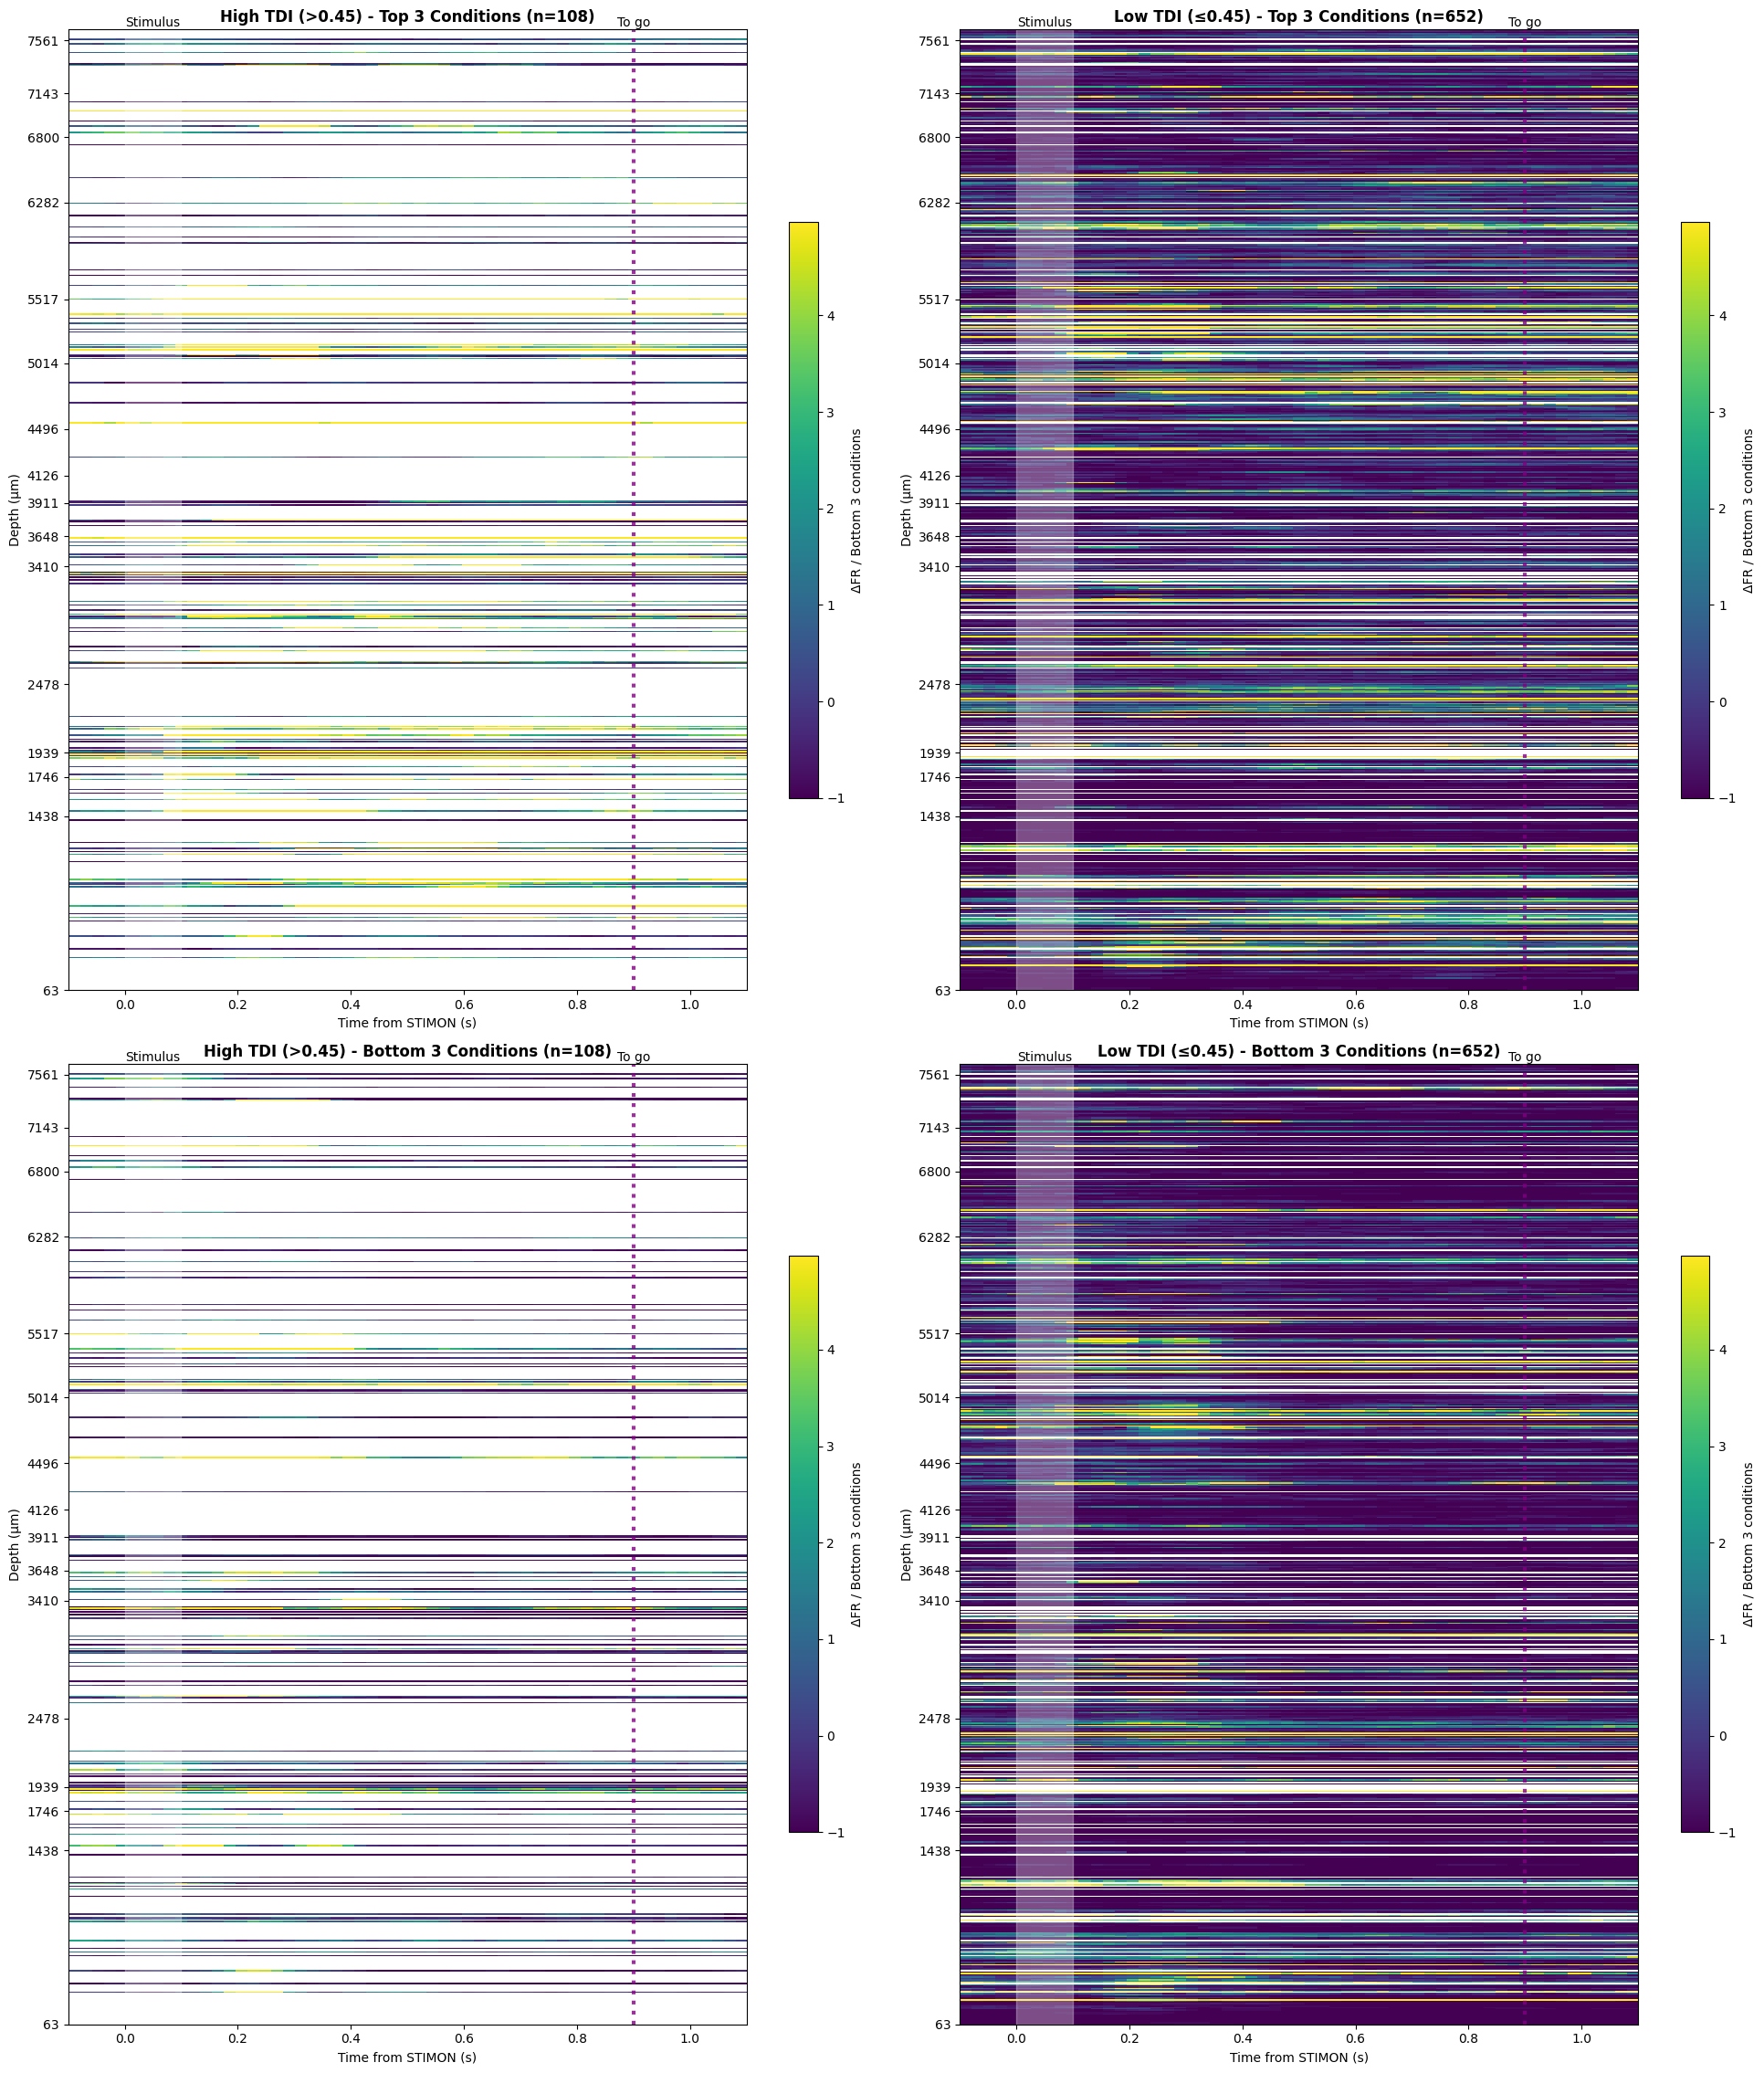

PSTH heatmap saved to: D:\Neural-Pipeline\data\20250801\psth_heatmap_sacc1350.png
Total clusters: 760
Valid TDI values: 690
Valid FR values: 760
Valid depth values: 760
Units in heatmap: 760
Depth range: 63 - 7648
Time bins: 57 bins from -0.10s to 1.02s
Completed processing D:\Neural-Pipeline\data\20250801


In [ ]:
for dataset in datasets:
    base_dir = dataset['base_dir']
    kilo_dir = dataset['kilo_dir']
    sacc_file = dataset['sacc_file']
    
    print(f"\n{'='*50}")
    print(f"Processing dataset: {base_dir}")
    print(f"Sacc file: {sacc_file}")
    print(f"{'='*50}")
    
    # Load data and process everything in one call
    data = NeuralDataLoader(base_dir, kilo_dir=kilo_dir, sacc_file=sacc_file,  tdi_threshold = 0.45)
    
    # Process all units and create comprehensive heatmap
    results = data.process_all_units_comprehensive(align_info)
    tdi_all, fr_all, depth_all, cluster_data_all, top_matrix, bottom_matrix, unit_info, time_bins = results
    
    print(f"Completed processing {base_dir}")

In [ ]:
cluster_data_all[0]['avg_firing_rates']

{'cluster_id': 0,
 'cluster_label': 'mua',
 'avg_firing_rates': {1: 0.1250000000000071,
  2: 0.0,
  3: 0.12499999999999822,
  4: 0.0,
  5: 0.0,
  6: 0.0,
  7: 0.3750000000000213,
  8: 0.0,
  9: 0.0,
  10: 0.0,
  11: 0.1250000000000071,
  12: 0.0,
  13: 0.0,
  14: 0.0,
  15: 0.0,
  16: 0.0,
  17: 0.1250000000000071,
  18: 0.0,
  19: 0.2500000000000142,
  20: 0.0},
 'tdi': 0.4275611390065075,
 'mean_fr': 0.056250000000002756,
 'depth': 65.65885,
 'index': 0}

In [15]:
plt.figure(figsize=(10, 8))

# Define leftward and rightward position indices based on angles
rightward_indices = []
leftward_indices = []

for i, angle in enumerate(angles):
    if angle < 90 or angle > 270:
        rightward_indices.append(i)
    elif 90 < angle < 270:
        leftward_indices.append(i)

# Convert to 1-based indexing
rightward_indices = [idx + 1 for idx in rightward_indices]
leftward_indices = [idx + 1 for idx in leftward_indices]

print(f"Rightward indices (1-based): {rightward_indices}")
print(f"Leftward indices (1-based): {leftward_indices}")

# Set firing rate threshold
fr_threshold = 2.0  # 2 spikes/second

# Filter data for units above threshold
filtered_tdi = []
filtered_depth = []
filtered_colors = []
filtered_preferences = []

for i, unit_data in enumerate(cluster_data_all):
    # Get average firing rates for this unit
    avg_rates = unit_data['avg_firing_rates']
    
    # Convert avg_rates to list if it's a dict
    if isinstance(avg_rates, dict):
        avg_rates_list = [avg_rates.get(i, 0) for i in range(1, 21)]
    else:
        avg_rates_list = list(avg_rates)
    
    # Get maximum firing rate
    max_fr = np.max(avg_rates_list)
    
    # Only process units above threshold
    if max_fr >= fr_threshold:
        # Add TDI and depth
        filtered_tdi.append(unit_data['tdi'])
        filtered_depth.append(unit_data['depth'])
        
        # Get firing rates for leftward and rightward positions
        leftward_rates = [avg_rates_list[idx-1] for idx in leftward_indices if idx-1 < len(avg_rates_list)]
        rightward_rates = [avg_rates_list[idx-1] for idx in rightward_indices if idx-1 < len(avg_rates_list)]
        
        # Get top 3 firing rates for each direction
        top_3_leftward = sorted(leftward_rates, reverse=True)[:3]
        top_3_rightward = sorted(rightward_rates, reverse=True)[:3]
        
        # Calculate means of top 3
        mean_top3_leftward = np.mean(top_3_leftward) if top_3_leftward else 0
        mean_top3_rightward = np.mean(top_3_rightward) if top_3_rightward else 0
        
        # Determine preference and color
        if mean_top3_rightward > mean_top3_leftward:
            filtered_preferences.append('rightward')
            filtered_colors.append('blue')
        elif mean_top3_leftward > mean_top3_rightward:
            filtered_preferences.append('leftward')
            filtered_colors.append('red')
        else:
            filtered_preferences.append('no_preference')
            filtered_colors.append('gray')

# Create scatter plot with only filtered units
scatter = plt.scatter(filtered_tdi, filtered_depth, alpha=0.7, s=60, c=filtered_colors, 
                     edgecolors='black', linewidth=0.5)

# Add TDI threshold line
plt.axvline(x=0.45, color='green', linestyle='--', linewidth=2, alpha=0.8, 
            label='TDI threshold = 0.45')

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', 
           markersize=10, label='Rightward preferring', markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', 
           markersize=10, label='Leftward preferring', markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
           markersize=10, label='No preference', markeredgecolor='black'),
    Line2D([0], [0], color='green', linestyle='--', linewidth=2, 
           label='TDI threshold = 0.45')
]
plt.legend(handles=legend_elements, loc='best')

# Labels and formatting
plt.xlabel('TDI (Tuning Depth Index)', fontsize=12)
plt.ylabel('Depth (μm)', fontsize=12)
plt.title(f'TDI vs Depth Distribution (FR > {fr_threshold} sp/s only)\n{os.path.basename(base_dir)} - {len(filtered_tdi)}/{len(cluster_data_all)} units', fontsize=14)
plt.grid(True, alpha=0.3)

# Count units by preference
rightward_count = filtered_colors.count('blue')
leftward_count = filtered_colors.count('red')
no_pref_count = filtered_colors.count('gray')

plt.text(0.02, 0.98, 
         f'Units shown: {len(filtered_tdi)}/{len(cluster_data_all)}\n'
         f'Rightward: {rightward_count}\n'
         f'Leftward: {leftward_count}\n'
         f'No preference: {no_pref_count}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()

# Save figure
tdi_plot_path = os.path.join(base_dir, f"tdi_vs_depth_filtered_fr{fr_threshold}_sacc{sacc_file}.png")
plt.savefig(tdi_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"TDI vs Depth plot (filtered) saved to: {tdi_plot_path}")
print(f"Units plotted: {len(filtered_tdi)} out of {len(cluster_data_all)} total")
print(f"Rightward preferring: {rightward_count}")
print(f"Leftward preferring: {leftward_count}")
print(f"No preference: {no_pref_count}")

Rightward indices (1-based): [1, 2, 9, 10, 11, 18, 19, 20]
Leftward indices (1-based): [5, 6, 12, 13, 14, 15, 16, 17]


NameError: name 'cluster_data_all' is not defined

<Figure size 1000x800 with 0 Axes>

### Save the data as MATLAB matrix

In [33]:
import scipy.io as sio

# Initialize lists to store data for MATLAB
unit_idx_list = []
tdi_list = []
contralateral_list = []  # 1 for left, 0 for right
top_position_fr_list = []

# Process each unit
for i, unit_data in enumerate(cluster_data_all):
    # Get TDI
    tdi_value = unit_data['tdi']
    
    # If TDI is None, skip this unit and add None/NaN to all fields
    if tdi_value is None or np.isnan(tdi_value):
        unit_idx_list.append(i)
        tdi_list.append(np.nan)
        contralateral_list.append(np.nan)
        top_position_fr_list.append(np.nan)
        continue
    
    # Get average firing rates
    avg_rates = unit_data['avg_firing_rates']
    
    # Convert avg_rates to list if it's a dict
    if isinstance(avg_rates, dict):
        avg_rates_list = [avg_rates.get(j, 0) for j in range(1, 21)]
    else:
        avg_rates_list = list(avg_rates)
    
    # Get firing rates for leftward and rightward positions
    leftward_rates = [avg_rates_list[idx-1] for idx in leftward_indices if idx-1 < len(avg_rates_list)]
    rightward_rates = [avg_rates_list[idx-1] for idx in rightward_indices if idx-1 < len(avg_rates_list)]
    
    # Get top 3 firing rates for each direction
    top_3_leftward = sorted(leftward_rates, reverse=True)[:3] if len(leftward_rates) >= 3 else leftward_rates
    top_3_rightward = sorted(rightward_rates, reverse=True)[:3] if len(rightward_rates) >= 3 else rightward_rates
    
    # Calculate means of top 3
    mean_top3_leftward = np.mean(top_3_leftward) if top_3_leftward else 0
    mean_top3_rightward = np.mean(top_3_rightward) if top_3_rightward else 0
    
    # Determine preference (1 for left/contralateral, 0 for right/ipsilateral)
    if mean_top3_leftward > mean_top3_rightward:
        contralateral = 1  # Left preference
    else:
        contralateral = 0  # Right preference (or equal)
    
    # Get maximum firing rate across all positions
    top_fr = np.max(avg_rates_list)
    
    # Add to lists
    unit_idx_list.append(i)
    tdi_list.append(tdi_value)
    contralateral_list.append(contralateral)
    top_position_fr_list.append(top_fr)

# Convert lists to numpy arrays
unit_idx_array = np.array(unit_idx_list, dtype=np.float64)
tdi_array = np.array(tdi_list, dtype=np.float64)
contralateral_array = np.array(contralateral_list, dtype=np.float64)
top_position_fr_array = np.array(top_position_fr_list, dtype=np.float64)

# Create MATLAB struct
matlab_data = {
    'unit_idx': unit_idx_array.reshape(-1, 1),  # Column vector
    'tdi': tdi_array.reshape(-1, 1),  # Column vector
    'contralateral': contralateral_array.reshape(-1, 1),  # Column vector (1=left, 0=right)
    'top_position_fr': top_position_fr_array.reshape(-1, 1),  # Column vector
    'dataset_info': {
        'base_dir': base_dir,
        'sacc_file': sacc_file,
        'n_units': len(unit_idx_list),
        'leftward_indices': np.array(leftward_indices),
        'rightward_indices': np.array(rightward_indices)
    }
}

# Save to MATLAB file
matlab_filename = os.path.join(base_dir, f"unit_direction_data_sacc{sacc_file}.mat")
sio.savemat(matlab_filename, matlab_data)

print(f"\nMATLAB data saved to: {matlab_filename}")
print(f"Total units: {len(unit_idx_list)}")
print(f"Units with valid TDI: {np.sum(~np.isnan(tdi_array))}")
print(f"Left preferring units: {np.nansum(contralateral_array == 1)}")
print(f"Right preferring units: {np.nansum(contralateral_array == 0)}")
print(f"Mean top firing rate: {np.nanmean(top_position_fr_array):.2f} sp/s")

# Optional: Create a summary CSV file as well
summary_df = pd.DataFrame({
    'unit_idx': unit_idx_list,
    'tdi': tdi_list,
    'contralateral': contralateral_list,
    'top_position_fr': top_position_fr_list
})

csv_filename = os.path.join(base_dir, f"unit_direction_summary_sacc{sacc_file}.csv")
summary_df.to_csv(csv_filename, index=False)
print(f"CSV summary saved to: {csv_filename}")


MATLAB data saved to: D:\Neural-Pipeline\data\20250801\unit_direction_data_sacc1350.mat
Total units: 760
Units with valid TDI: 690
Left preferring units: 349
Right preferring units: 341
Mean top firing rate: 4.73 sp/s
CSV summary saved to: D:\Neural-Pipeline\data\20250801\unit_direction_summary_sacc1350.csv


### Plot TDI by depth


Processing dataset: D:\Neural-Pipeline\data\20250724
Sacc file: 1702
Selected base directory: D:\Neural-Pipeline\data\20250724
Loading kilosort data...
Filtering TTL data for block 1702
Parsed 176 trials, 84 good trials.
Using PHY cluster labels and depths for 127 good clusters
Processing TDI of cluster: 6
Processing TDI of cluster: 7
Processing TDI of cluster: 9
Processing TDI of cluster: 10
Processing TDI of cluster: 11
Processing TDI of cluster: 14
Processing TDI of cluster: 16
Processing TDI of cluster: 18
Processing TDI of cluster: 19
Processing TDI of cluster: 23
Processing TDI of cluster: 25
Processing TDI of cluster: 27
Processing TDI of cluster: 28
Processing TDI of cluster: 42
Processing TDI of cluster: 45
Processing TDI of cluster: 47
Processing TDI of cluster: 52
Processing TDI of cluster: 53
Processing TDI of cluster: 56
Processing TDI of cluster: 66
Processing TDI of cluster: 69
Processing TDI of cluster: 68
Processing TDI of cluster: 73
Processing TDI of cluster: 74
Pro

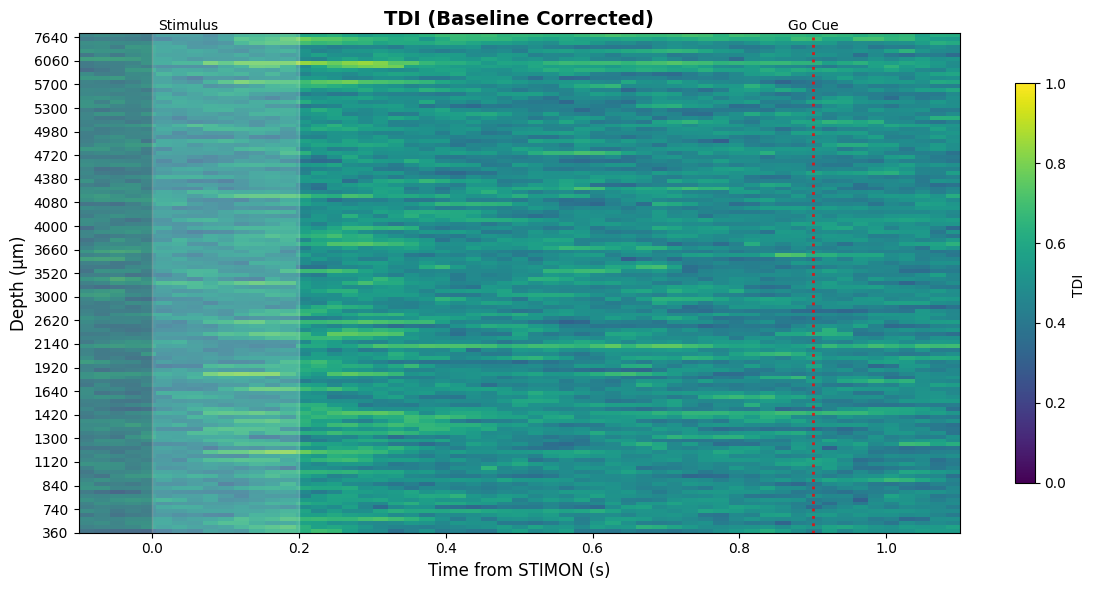

TDI heatmap saved to: D:\Neural-Pipeline\data\20250724\tdi_heatmap_baseline_corrected_sacc1702.png
Completed processing D:\Neural-Pipeline\data\20250724


In [2]:
phy = True
for dataset in datasets:
    base_dir = dataset['base_dir']
    kilo_dir = dataset['kilo_dir']
    sacc_file = dataset['sacc_file']
    phy_dir = dataset['phy_dir']

    
    print(f"\n{'='*50}")
    print(f"Processing dataset: {base_dir}")
    print(f"Sacc file: {sacc_file}")
    print(f"{'='*50}")
    
    # Load data and process everything in one call
    data = NeuralDataLoader(base_dir, kilo_dir = phy_dir, sacc_file = sacc_file, phy = phy)
    
    # Process all units and create comprehensive heatmap
    results = data.create_comprehensive_tdi_heatmap(align_info)
    
    print(f"Completed processing {base_dir}")

In [21]:
tdi_baseline_corrected, valid_units, time_bins = results
tdi_time_indices = np.where((time_bins >0.2) & (time_bins <0.4))[0]
# scatter plot of TDI vs Depth
for i, unit in enumerate(valid_units):
    depth = valid_units[i]['depth']
    tdi_mean = np.mean(tdi_baseline_corrected[i][tdi_time_indices])
    print(tdi_mean, depth)
    plt.scatter(tdi_mean, depth, label=f"Unit {unit['cluster_id']}")
# tdi_baseline_corrected[0]
# valid_units[0]['depth']

NameError: name 'results' is not defined